In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("student_performance_dataset.csv")
df.head()

,student_id,gender,branch,cgpa,attendance,internships,coding_score,communication_score,placed,salary_lpa
0,1,Female,IT,7.85,90.2,0,69.0,75.0,No,0.00
1,2,Female,CSE,6.73,80.4,0,56.0,46.0,No,0.00
2,3,Male,IT,6.19,NaN,0,54.0,NaN,No,0.00
3,4,Male,CSE,6.66,76.1,1,60.0,74.0,Yes,4.95
4,5,Male,CSE,9.05,83.2,0,46.0,100.0,Yes,7.31


In [3]:
print(df.columns)

Index(['student_id', 'gender', 'branch', 'cgpa', 'attendance', 'internships',
       'coding_score', 'communication_score', 'placed', 'salary_lpa'],
      dtype='object')


In [4]:
#Data Cleaning and Preprocessing
df.describe()

,student_id,cgpa,attendance,internships,coding_score,communication_score,salary_lpa
count,300.000000,279.000000,279.000000,300.000000,279.000000,279.000000,283.000000
mean,150.500000,7.206416,74.571685,0.940000,68.964158,59.275986,3.520000
std,86.746758,0.938223,10.557197,0.941286,14.708638,14.700334,3.341471
min,1.000000,4.600000,46.300000,0.000000,25.000000,21.000000,0.000000
25%,75.750000,6.540000,67.150000,0.000000,59.000000,50.000000,0.000000
50%,150.500000,7.170000,75.700000,1.000000,69.000000,59.000000,4.450000
75%,225.250000,7.850000,81.500000,2.000000,78.000000,68.500000,6.710000
max,300.000000,9.380000,95.000000,3.000000,100.000000,100.000000,9.880000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           300 non-null    int64  
 1   gender               300 non-null    object 
 2   branch               300 non-null    object 
 3   cgpa                 279 non-null    float64
 4   attendance           279 non-null    float64
 5   internships          300 non-null    int64  
 6   coding_score         279 non-null    float64
 7   communication_score  279 non-null    float64
 8   placed               300 non-null    object 
 9   salary_lpa           283 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 23.6+ KB


In [6]:
#Checking null values
df.isnull().sum()

student_id              0
gender                  0
branch                  0
cgpa                   21
attendance             21
internships             0
coding_score           21
communication_score    21
placed                  0
salary_lpa             17
dtype: int64

In [7]:
#Handling missing values
# CGPA (branch-wise mean)
df['cgpa']=df['cgpa'].fillna(df.groupby('branch')['cgpa'].transform('mean'))
#Making CGPA round off
df['cgpa'] = df['cgpa'].round(1)

df['attendance']=df['attendance'].fillna(df['attendance'].median())

# Coding score (branch-wise mean)
df['coding_score'] = df['coding_score'].fillna(
    df.groupby('branch')['coding_score'].transform('mean'))
df['coding_score'] = df['coding_score'].round(1)

# Communication score (branch-wise mean)
df['communication_score'] = df['communication_score'].fillna(
    df.groupby('branch')['communication_score'].transform('mean'))
df['communication_score'] = df['communication_score'].round(1)

# Salary handling
df.loc[df['placed'] == 'No', 'salary_lpa'] = 0

df['salary_lpa'] = df['salary_lpa'].fillna(
    df.groupby('branch')['salary_lpa'].transform('median'))

In [8]:
df.isnull().sum()

student_id             0
gender                 0
branch                 0
cgpa                   0
attendance             0
internships            0
coding_score           0
communication_score    0
placed                 0
salary_lpa             0
dtype: int64

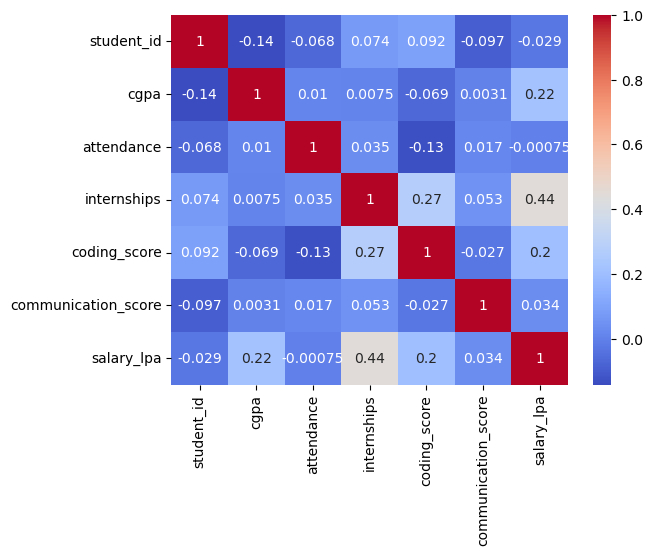

In [9]:
#Graphs
import seaborn as sns
import matplotlib.pyplot as plt

#1. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

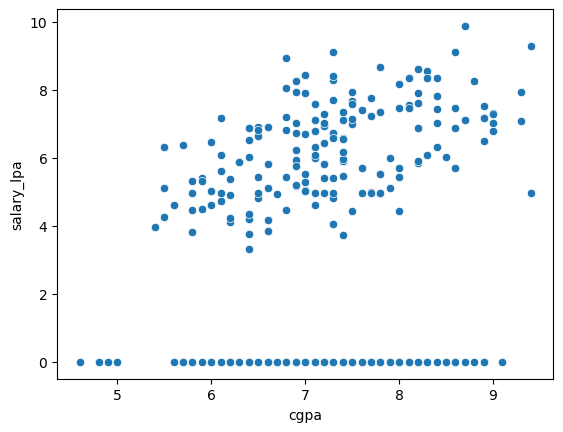

In [10]:
#2. CGPA vs Salary
sns.scatterplot(x='cgpa', y='salary_lpa', data=df)
plt.show()

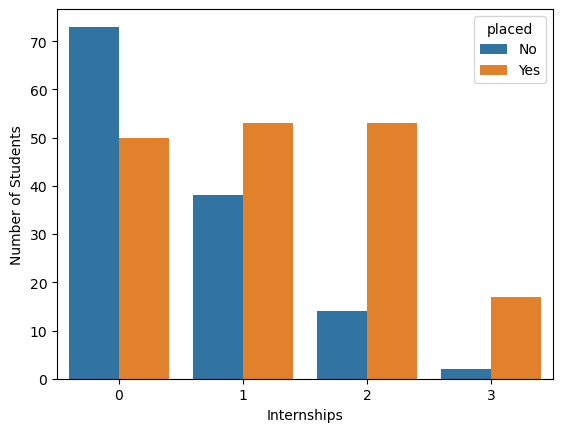

In [11]:
#3. Internships vs Placement
sns.countplot(x='internships', hue='placed', data=df)
plt.xlabel("Internships")
plt.ylabel("Number of Students")
plt.show()

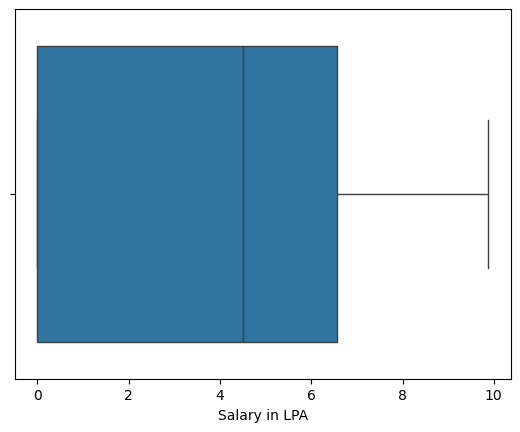

In [12]:
#4. Salary Distribution
sns.boxplot(x='salary_lpa', data=df)
plt.xlabel("Salary in LPA")
plt.show()

In [13]:
# Insights
#1 Students with higher CGPA have better chances of getting placed.
#2 Internships increase the probability of a student to get placed.
#3 Average Salary of the students is around 4.5 LPA.
#4 Some students with high CGPA are still unplaced, that means other factors matter.

In [14]:
df = df.where(pd.notnull(df), None)

In [15]:
df.to_csv("students_cleaned.csv", index=False)